# Analyse van de routes

In [1]:
import os
import json
from datetime import datetime
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
ROUTEDIR = "..\\data\\input\\responses\\"
ROUTEREQ = "..\\data\\input\\requests\\"

## Gemeenschappelijk functies

In [3]:

#############################################################################
# Vinden van de tijd in een file met de route                               #
#############################################################################
def extract_hour_from_filename(filename):
    # voorbeeld: 0521_302-20220602-082202-114-0.txt
    parts = filename.replace(".txt", "").split("-")
    time_part = parts[2]      # 082202

    hour = int(time_part[:2])  # eerste twee tekens = uur
    return hour

###########################################################################
# Opstellen van een lijst met routes. De lijst is de eerste en de laatste #
# route van de voormiddag                                                 #
###########################################################################
def list_of_first_and_last_route():
    ListOfCorrespondingFiles = []

    for root, dirs, files in os.walk(ROUTEDIR,topdown=True):
        correspondingFiles = []
        if len(files) == 0:
            continue
        files.sort() # om zeker te zijn

        if extract_hour_from_filename(files[0]) >= 12: # als de eerste file al vzn na 12 uur dateert is dit geen route
            continue

        # eerste entry is voor 12 uur - vind nu de laatste voor 12 uur
        correspondingFiles.append(files[0]) # toevoegen
        for i in range (len(files)):
            if extract_hour_from_filename(files[i]) >= 12:
                break
            lastfile = max(i,0) # max omdat het ook kan zijn dat er maar 1 file is            
        correspondingFiles.append(files[lastfile])
        correspondingFiles.append(os.path.basename(root))
        ListOfCorrespondingFiles.append(correspondingFiles)

    return ListOfCorrespondingFiles

#############################################################################
# Bepaal een identifier
#############################################################################
def maak_identifier (lattitude, longitude):


    identifier = (lattitude.round(8).astype(str)
        + "_"
        + longitude.round(8).astype(str)
        )
    return identifier


#############################################################################
# Aanmaak van het dataframe van een route                                   #
# krijgt argument filenaam&rootdirectory - zoekt de request file en haalt   # 
# daar de lattitude en logitude uit                                         #
#############################################################################


def maak_route_dataframe(responsefilename, directory):
    # bepaal de overeenkomstige requestfile
    requestfilename = responsefilename.replace(".txt", ".json")


    # geeft terug : een dataframe met de locaties in volgorde van de response.
    with open(os.path.join(ROUTEREQ, directory,requestfilename), "r") as f:
        request = json.load(f)
    tasks = request["tasks"]  # data["tasks"] is een lijst van dictionaries
    df_Request = pd.json_normalize(tasks)  # json_normalize maakt geneste structuren plat
    
    df_Request["Identifier"] = maak_identifier(df_Request["address.latitude"],df_Request["address.longitude"])
    df_Request["Previous identifier"] = df_Request["Identifier"].shift(1)

    df_response = pd.read_csv(os.path.join(ROUTEDIR,directory,responsefilename), header=None, names=["tasks"])


    df_response["tasks"] = df_response["tasks"].astype(str)
    df_Request["id"] = df_Request["id"].astype(str)
    df_result = df_response.merge(df_Request,left_on="tasks",right_on="id", how="left")

    df_result = afstand_vlak_tot_vorige(df_result)

    return df_result


#############################################################################
# Voeg de afstanden toe                                                     #
#############################################################################
def afstand_vlak_tot_vorige(df, lat_col="address.latitude", lon_col="address.longitude",
                            new_col="afstand_km"):
    lat = df[lat_col]
    lon = df[lon_col]

    lat_prev = lat.shift(1)
    lon_prev = lon.shift(1)

    dlat_km = (lat - lat_prev) * 111
    dlon_km = (lon - lon_prev) * 111 * np.cos(np.radians(lat))

    df[new_col] = np.sqrt(dlat_km**2 + dlon_km**2)
    return df

#############################################################################
# Vergelijk 2 routes                                                        #
#############################################################################

import pandas as pd

def vergelijk_routes(route1_df, route2_df):

    ids_eerste  = set(route1_df["Identifier"])
    ids_laatste = set(route2_df["Identifier"])

    # -------------------------
    # segmenten (stukken) maken
    # -------------------------
    def maak_segmenten(df):
        seg_df = df[["Previous identifier", "Identifier"]].dropna()

        seg = [
            (a, b)
            for a, b in zip(seg_df["Previous identifier"], seg_df["Identifier"])
            if a != b
        ]
        return set(seg)

    seg1 = maak_segmenten(route1_df)
    seg2 = maak_segmenten(route2_df)

    gelijke_stukken = len(seg1 & seg2)
    verschillende_stukken = len(seg1 - seg2)

    # -------------------------
    # metrics
    # -------------------------
    result_df = pd.DataFrame([{
        "EersteAantalPunten": len(route1_df),
        "EersteNietTweede": len(ids_eerste - ids_laatste),
        "LengteEerste": route1_df["afstand_km"].sum(skipna=True),
        "AvgLengteEerste": route1_df["afstand_km"].mean(skipna=True),
        "MaxLengteEerste": route1_df["afstand_km"].max(skipna=True),
        "EersteDubbel": route1_df["Identifier"].duplicated().sum(),

        "TweedeAantalPunten": len(route2_df),
        "TweedeNietEerste": len(ids_laatste - ids_eerste),
        "LengteTweede": route2_df["afstand_km"].sum(skipna=True),
        "AvgLengteTweede": route2_df["afstand_km"].mean(skipna=True),
        "MaxLengteTweede": route2_df["afstand_km"].max(skipna=True),
        "TweedeDubbel": route2_df["Identifier"].duplicated().sum(),

        "AantalGelijkeStukken": gelijke_stukken,
        "AantalVerschillendeStukken": verschillende_stukken
    }])

    
    return result_df






## hier wordt het dataframe gebouwd waarmee de analyse zal gebeuren

In [5]:
routelist = list_of_first_and_last_route()

overview = pd.DataFrame()
routefiles = pd.DataFrame()


for route in routelist:
    firstroute_df = maak_route_dataframe(route[0], route[2])
    lastroute_df = maak_route_dataframe(route[1], route[2])

    routefiles = pd.DataFrame({
        "FirstFile": [route[0]],
        "LastFile":  [route[1]],
        "base":      [route[2]]
    })
   
    row = pd.concat(
        [routefiles, vergelijk_routes(firstroute_df, lastroute_df)],
        axis=1
        )
    
    overview = pd.concat([overview, row], ignore_index=True)

   
overview.to_excel(os.path.join("../data/intermediate","routeinformation.xlsx"), index=False)

# Vanaf hier gebeurt de analyse - de XLS bevat de data die werd ingelezen

### de imports en de routes eerst runnen - anders werkt het hieronder niet - herdoe gerust als de dataframe beschadigd werd. Je start steeds opnieuw

### sectie voor het vergelijken van dezelfde routes. 

1. DF inlezen
2. rijen vastleggen waar de punten onveranderd bleven
3. relatie vastleggen
4. 

In [4]:
overview = pd.read_excel(os.path.join("../data/intermediate","routeinformation.xlsx"))

In [5]:
####  Verwijder de routes die onveranderd gebleven zijn ###### -> dat zijn er eigenlijk bijna geen
overview = overview[overview["AantalVerschillendeStukken"] > 0].reset_index(drop=True)

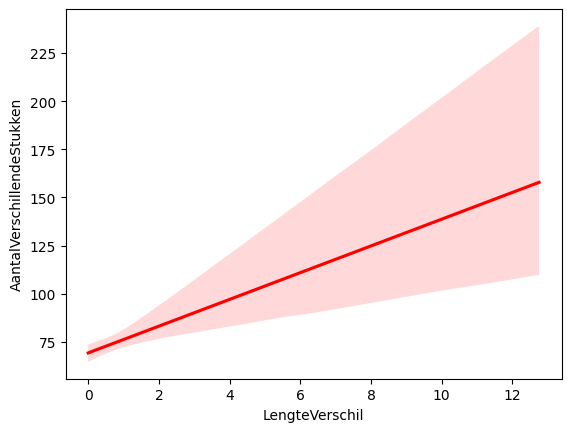

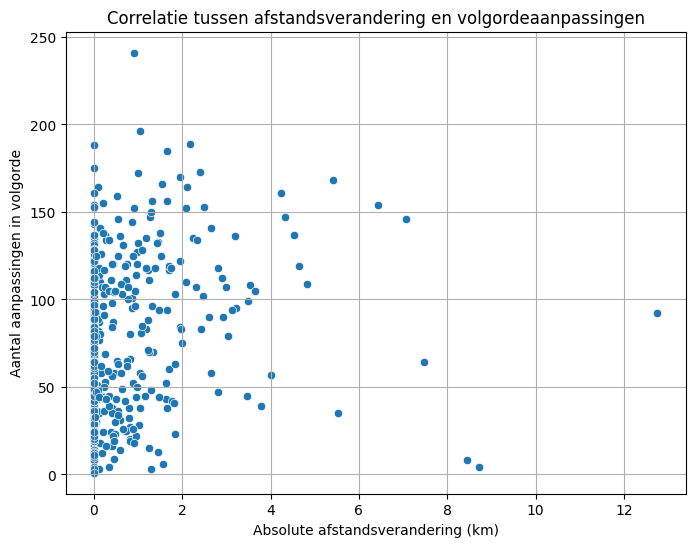

In [6]:
#### eerste analyse op routes met exact dezelfde punten -> we kijken enkel naar de effecten van de aanpassing van de routevolgorde
# Alleen routes waarvan de sets van identifiers exact gelijk zijn
overview = overview[
    (overview["EersteNietTweede"] == 0) & (overview["TweedeNietEerste"] == 0)
].reset_index(drop=True)

# Zorg dat lengteverschil kolom aanwezig is
overview["LengteVerschil"] = (overview["LengteTweede"] - overview["LengteEerste"]).abs()

# Optioneel: regressielijn toevoegen
sns.regplot(
    data=overview,
    x="LengteVerschil",
    y="AantalVerschillendeStukken",
    scatter=False,  # alleen lijn
    color="red"
)

# Scatterplot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=overview,
    x="LengteVerschil",
    y="AantalVerschillendeStukken"
)



plt.xlabel("Absolute afstandsverandering (km)")
plt.ylabel("Aantal aanpassingen in volgorde")
plt.title("Correlatie tussen afstandsverandering en volgordeaanpassingen")
plt.grid(True)
plt.show()



#### Als ik dat zo bekijk is de regressielijn toch iets raar. We zien soms een grote aanpassing van segmenten zonder een significante verbetering . Het lijkt wel dat de verbeteringen beperkt zijn.

In [7]:

################################################################################################
# Visualisatie van de routes                                                                   #
################################################################################################


def toon_file(base_keuze):
    row_sel = overview[overview["base"] == base_keuze].iloc[0]

    df_first = maak_route_dataframe(row_sel["FirstFile"], row_sel["base"])
    df_last  = maak_route_dataframe(row_sel["LastFile"], row_sel["base"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # ---------- FIRST FILE ----------
    ax = axes[0]
    ax.plot(df_first["address.longitude"],
            df_first["address.latitude"],
            marker="o")

    ax.set_title("FirstFile route")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True)

    # ---------- LAST FILE ----------
    ax = axes[1]
    ax.plot(df_last["address.longitude"],
            df_last["address.latitude"],
            marker="o")

    ax.set_title("LastFile route")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True)

    plt.tight_layout()
    plt.show()

    print ("Hello World")


bases = sorted(overview["base"].dropna().unique())

dropdown = widgets.Dropdown(
    options=bases,
    description="Base:",
)

widgets.interact(toon_file, base_keuze=dropdown)

interactive(children=(Dropdown(description='Base:', options=('0521_301-20220613', '0521_301-20220618', '0521_3…

<function __main__.toon_file(base_keuze)>

### Wanneer punten worden toegevoegd en volgorde aangepast - op dat moment kan je niet langer naar de totale lengte kijken, wel naar de gemiddelde lengte van de segmenten

1. DF opnieuw inlezen (houdt de boel wat bij mekaar)
2. Selectie van de rijen waar er wel een verschil zit
3. Opstellen van de grafieken

In [8]:
overview = pd.read_excel(os.path.join("../data/intermediate","routeinformation.xlsx"))
####  Verwijder de routes die onveranderd gebleven zijn ###### -> dat zijn er eigenlijk bijna geen
overview = overview[overview["AantalVerschillendeStukken"] > 0].reset_index(drop=True)

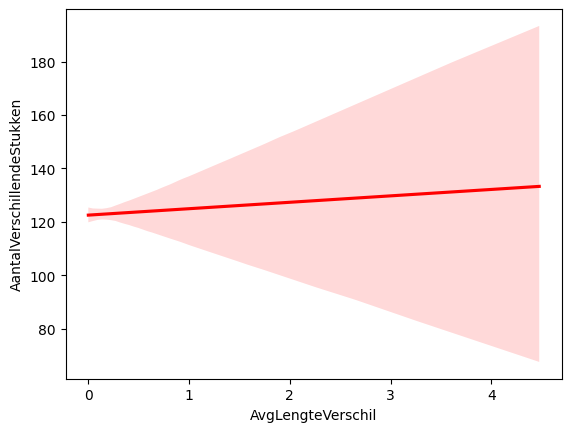

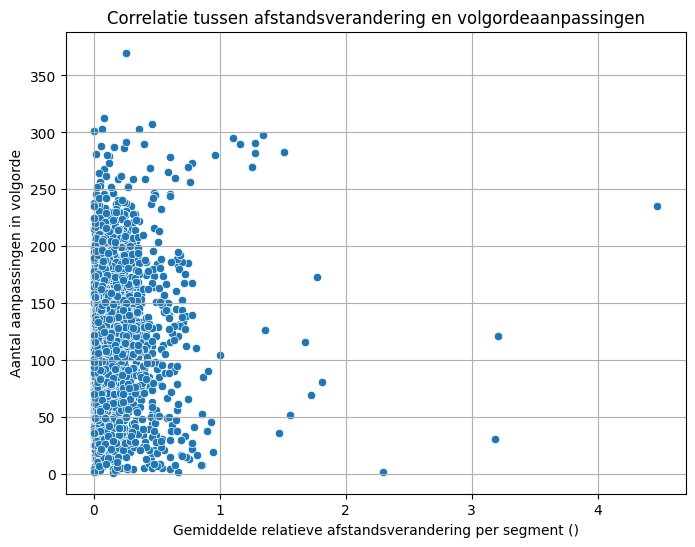

In [10]:
#### eerste analyse op routes met exact dezelfde punten -> we kijken enkel naar de effecten van de aanpassing van de routevolgorde
# Alleen routes waarvan de sets van identifiers exact gelijk zijn
overview = overview[
    (overview["EersteNietTweede"] > 0) | (overview["TweedeNietEerste"] > 0)
].reset_index(drop=True)

# Zorg dat AVGlengteverschilsegmenten kolom aanwezig is
overview["AvgLengteVerschil"] = ((overview["AvgLengteTweede"] - overview["AvgLengteEerste"]).abs())/overview["AvgLengteEerste"]

# Optioneel: regressielijn toevoegen
sns.regplot(
    data=overview,
    x="AvgLengteVerschil",
    y="AantalVerschillendeStukken",
    scatter=False,  # alleen lijn
    color="red"
)

# Scatterplot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=overview,
    x="AvgLengteVerschil",
    y="AantalVerschillendeStukken"
)



plt.xlabel("Gemiddelde relatieve afstandsverandering per segment ()")
plt.ylabel("Aantal aanpassingen in volgorde")
plt.title("Correlatie tussen afstandsverandering en volgordeaanpassingen")
plt.grid(True)
plt.show()


#### ook hier bijna geen trend waar te nemen

### Enkel testjes - nog geen startegie beoogd

In [24]:
###############################################################################
# selecteer de routes waar geen andere punten werden toegevoegd of verwijderd #
###############################################################################

overview = overview[
    (overview["EersteNietTweede"] == 0) & 
    (overview["TweedeNietEerste"] == 0)
]

In [12]:

overview["LengteVerandering_pct"] = (
    (overview["LengteTweede"] - overview["LengteEerste"]) 
    / overview["LengteEerste"]
) * 100

##### check of er een correlatie is tussen het lengteverschil en het aantal veranderde segmenten

In [25]:
overview["LengteVerschil"] = (
    overview["LengteTweede"] - overview["LengteEerste"]
).abs()

In [26]:
overview

,FirstFile,LastFile,base,EersteAantalPunten,EersteNietTweede,LengteEerste,AvgLengteEerste,MaxLengteEerste,EersteDubbel,TweedeAantalPunten,TweedeNietEerste,LengteTweede,AvgLengteTweede,MaxLengteTweede,TweedeDubbel,AantalGelijkeStukken,AantalVerschillendeStukken,LengteVerschil
1,0521_301-20220530-064538-154-154.txt,0521_301-20220530-064538-154-154.txt,0521_301-20220530,154,0,12.779945,0.083529,0.670521,33,154,0,12.779945,0.083529,0.670521,33,121,0,0.000000
10,0521_301-20220613-060743-148-0.txt,0521_301-20220613-065320-145-145.txt,0521_301-20220613,148,0,13.134725,0.089352,0.648842,29,145,0,12.264247,0.085168,0.415306,26,2,144,0.870479
15,0521_301-20220618-053622-49-0.txt,0521_301-20220618-055328-49-49.txt,0521_301-20220618,49,0,10.883896,0.226748,0.912533,3,49,0,10.883896,0.226748,0.912533,3,6,42,0.000000
44,0521_303-20220610-060922-126-126.txt,0521_303-20220610-060954-126-126.txt,0521_303-20220610,126,0,12.559776,0.100478,0.745149,22,126,0,12.559776,0.100478,0.745149,22,110,0,0.000000
57,0521_304-20220604-052800-50-0.txt,0521_304-20220604-054512-50-50.txt,0521_304-20220604,50,0,22.436642,0.457891,2.545215,3,50,0,23.727894,0.484243,2.545215,3,1,48,1.291252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3297,0521_O69-20220601-070556-140-0.txt,0521_O69-20220601-081749-140-140.txt,0521_O69-20220601,140,0,12.705972,0.091410,0.751601,16,140,0,12.708389,0.091427,0.751601,16,47,82,0.002417
3301,0521_O69-20220608-064944-146-0.txt,0521_O69-20220608-083530-146-146.txt,0521_O69-20220608,146,0,11.834796,0.081619,0.412316,24,146,0,12.318796,0.084957,0.412316,24,24,105,0.484000
3303,0521_O69-20220610-072003-140-0.txt,0521_O69-20220610-073132-140-140.txt,0521_O69-20220610,140,0,13.857153,0.099692,0.449996,13,140,0,13.857153,0.099692,0.449996,13,19,112,0.000000
3306,0521_O69-20220615-071130-139-0.txt,0521_O69-20220615-083538-139-139.txt,0521_O69-20220615,139,0,13.821731,0.100157,0.655032,11,139,0,14.592271,0.105741,0.610954,11,25,107,0.770540
